(10, 0.5)
(50, 0.44)
(100, 0.44)
(500, 0.51)
(1000, 0.478)
(10000, 0.5034)
(50000, 0.49918)


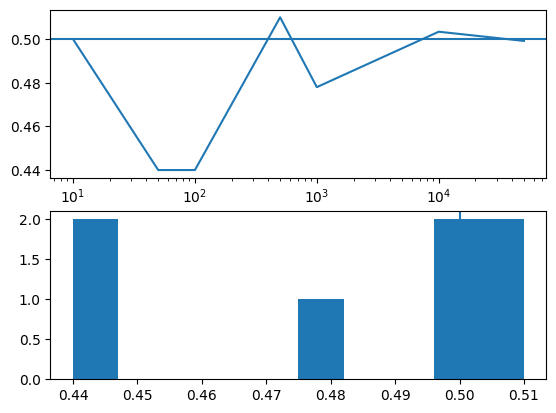

In [2]:
"""
Module 5: Probability Through Simulation
Goal: Build intuition by running experiments

Monte Carlo Approach:
Instead of deriving formulas, run thousands of random simulations and 
watch probabilities emerge. This builds deep intuition.
"""

import numpy as np
from typing import List, Tuple
from collections import Counter
import matplotlib.pyplot as plt
import scipy.stats

"""
Part 1: Law of Large Numbers
"""
def flip_coin(n_flips: int) -> float:
    """
    Simulat coin flips and return proportion of heads.

    This demonstrates the Law of Large Numbers:
    As n_flips increases, the proportion converges to 0.5

    Args:
        n_flips: Number of coins to flip
    
    Returns:
        Proportion of heads (between 0 and 1)
    
    Example:
        >>> flip_coin(10) #mighht return .6
        >>> flip_coin(10000) # very close to 0.5

    """
    results = []
    for i in range(n_flips):
        result = np.random.choice(['H','T'])
        results.append(result)
    counts = Counter(results)
    heads = counts['H']
    tails = counts['T']

    return heads / (heads + tails)

n_trials = [10, 50, 100, 500, 1000, 10000, 50000]
n_results = []
for n in n_trials:
    n_results.append((n,flip_coin(n)))
for result in n_results:
    print(result)
trials, proportions = zip(*n_results)
fig,axes = plt.subplots(2,1)
axes[0].plot(trials, proportions)
axes[0].set_xscale('log')
axes[0].axhline(y=0.5)

axes[1].hist(proportions)
axes[1].axvline(x=0.5)

plt.show()








3.5049
2.94697599


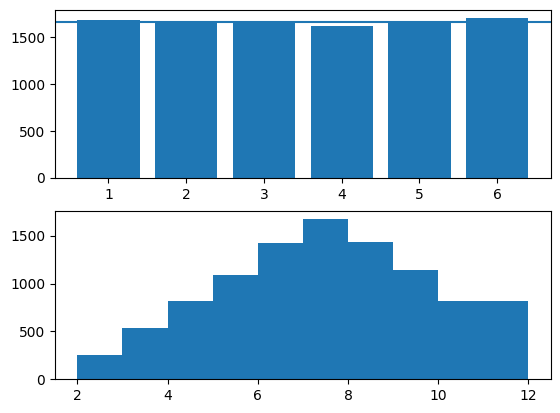

In [3]:
"""
Part 2: Discrete Distributions - Dice Rolls
"""

def roll_die(n_rolls: int) -> np.ndarray:
    """
    Simulate rolling a fair 6-sided die.

    Args:
        n_rolls: Number of times to roll the die
    
    Returns:
        Array of outcomes (values 1-6)
    """

    return np.random.randint(1,7, size=n_rolls)

counts = roll_die(10000)
mean = np.mean(counts)
var = np.var(counts)
freq = Counter(counts)

print(mean)
print(var)
faces = freq.keys()
frequencies = freq.values()
fig,axes = plt.subplots(2,1)
axes[0].bar(faces, frequencies)
axes[0].axhline(y=1667)


die1 = roll_die(10000)
die2 = roll_die(10000)

sums = die1+die2
axes[1].hist(sums)
plt.show()



Part3: Continuous Distributions

Normal Distribution N(0, 1²):
  Empirical mean: 0.0092
  Empirical std: 0.9899
Uniform Distribution:
  Empirical mean: 0.5048
  Empirical std: 0.2886
Exponential Distribution
  Empirical mean: 0.9823
  Empirical std: 0.9692
Binomial Distribution
  Empirical mean: 2.9897
  Empirical std: 1.4377


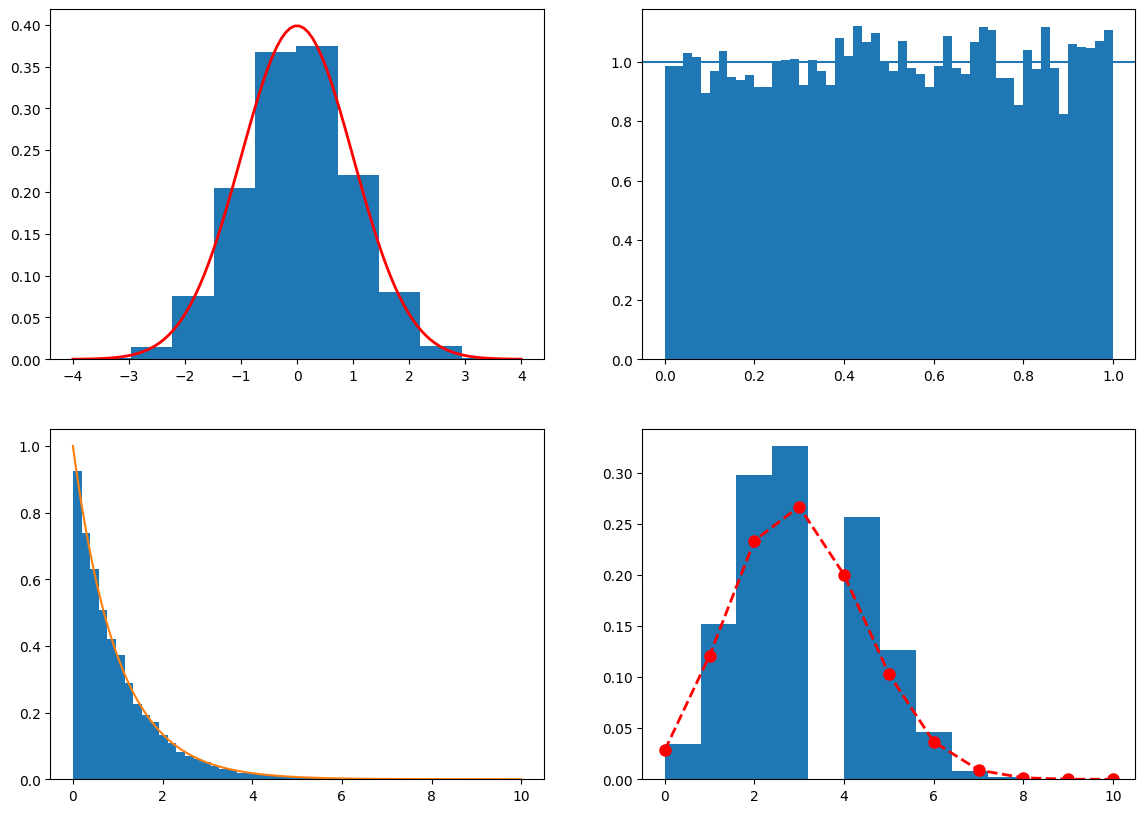

In [10]:
 
print("\n"+ "="*60)
print("Part3: Continuous Distributions")
print("="*60)

mu = 0 # mean
sigma = 1 # standard deviation
n_samples = 10000
normal_samples = np.random.normal(mu, sigma, n_samples)

print(f"\nNormal Distribution N({mu}, {sigma}²):")
print(f"  Empirical mean: {np.mean(normal_samples):.4f}")
print(f"  Empirical std: {np.std(normal_samples):.4f}")

x_values = np.linspace(-4,4,100)
y_values = scipy.stats.norm.pdf(x_values, mu, sigma)
fig, axes = plt.subplots(2,2, figsize=(14,10))
axes[0,0].hist(normal_samples, density=True)
axes[0,0].plot(x_values, y_values, color='red', linewidth=2)


uniform_samples = np.random.uniform(0,1, n_samples)
u_mean = np.mean(uniform_samples)
u_std = np.std(uniform_samples)
print("Uniform Distribution:")
print(f"  Empirical mean: {u_mean:.4f}")
print(f"  Empirical std: {u_std:.4f}")

axes[0,1].hist(uniform_samples, bins=50, density=True)
axes[0,1].axhline(y=1)

exponential_samples = np.random.exponential(1, n_samples)
print("Exponential Distribution")
e_mean = np.mean(exponential_samples)
e_std = np.std(exponential_samples)
print(f"  Empirical mean: {e_mean:.4f}")
print(f"  Empirical std: {e_std:.4f}")

x_values = np.linspace(0,10, 1000)
pdf = scipy.stats.expon.pdf(x_values,scale=1)
axes[1,0].hist(exponential_samples, bins=50, density=True)
axes[1,0].plot(x_values, pdf)

print("Binomial Distribution")
binomial_samples = np.random.binomial(n=10, p=0.3, size=n_samples)
b_mean = np.mean(binomial_samples)
b_std = np.std(binomial_samples)
print(f"  Empirical mean: {b_mean:.4f}")
print(f"  Empirical std: {b_std:.4f}")

x_values = np.arange(0,11)
pmf = scipy.stats.binom.pmf(x_values, n=10, p=0.3)
axes[1,1].hist(binomial_samples, density=True)
axes[1,1].plot(x_values, pmf, 'ro--', linewidth=2, markersize=8, label='Theoretical PMF')

plt.show()